<a href="https://colab.research.google.com/github/VinayakTanwar/Food-Delivery-Time-Prediction-Case-Study/blob/main/insurence_project_ml_ready.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sea
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# **EDA**

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

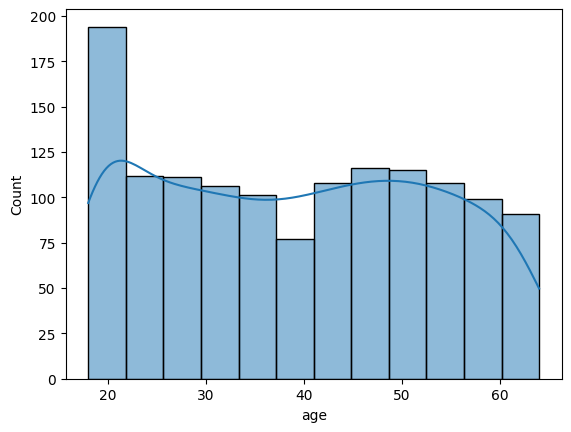

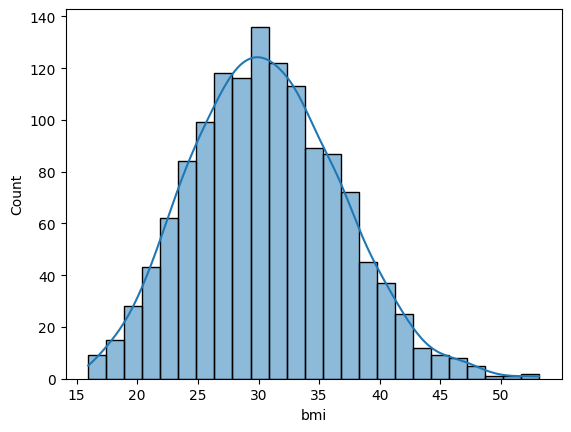

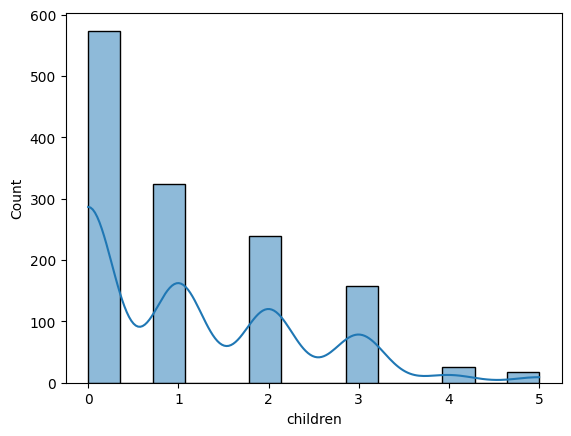

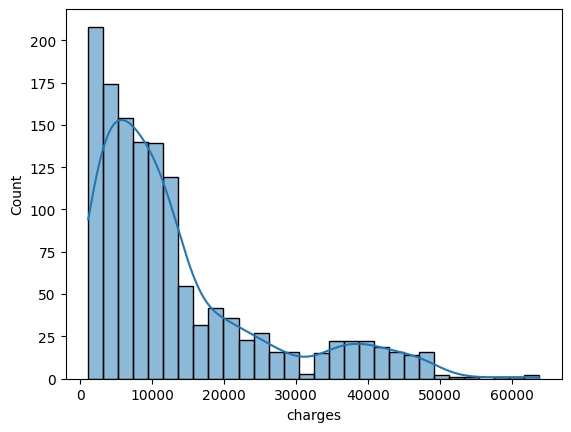

In [ ]:
no_columns = ['age', 'bmi', 'children','charges']
for col in no_columns:
  sea.histplot(df[col], kde = True)
  plt.show()

<Axes: xlabel='children', ylabel='count'>

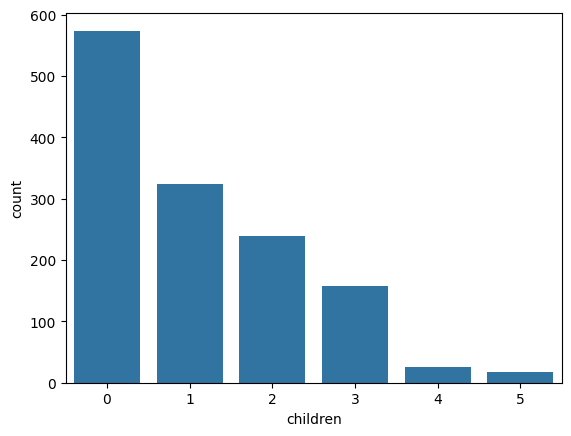

In [ ]:
sea.countplot(x= df['children'])

<Axes: xlabel='sex', ylabel='count'>

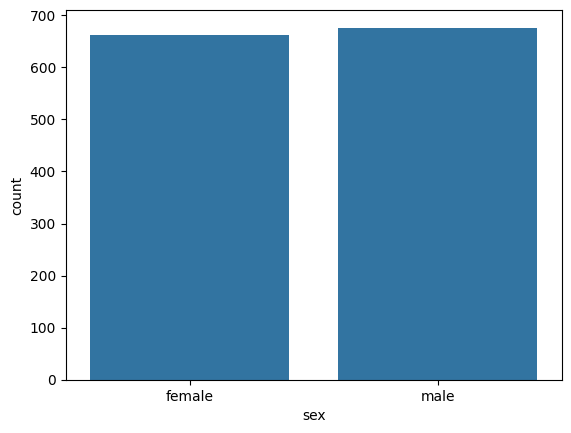

In [ ]:
sea.countplot(x= df['sex'])

<Axes: xlabel='charges', ylabel='Count'>

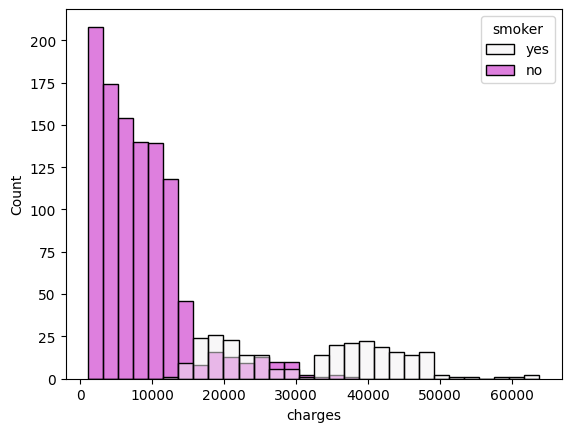

In [ ]:
sea.histplot(x= df['charges'], hue = df['smoker'], palette = 'light:m')

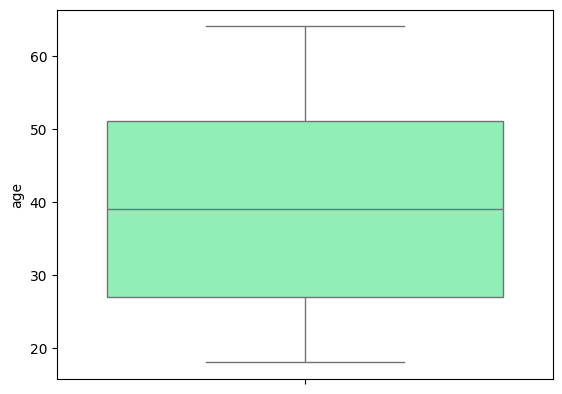

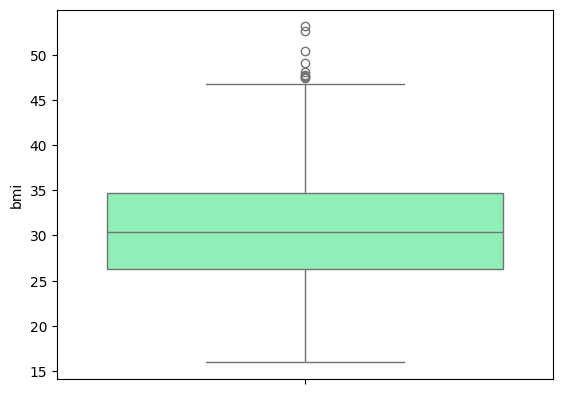

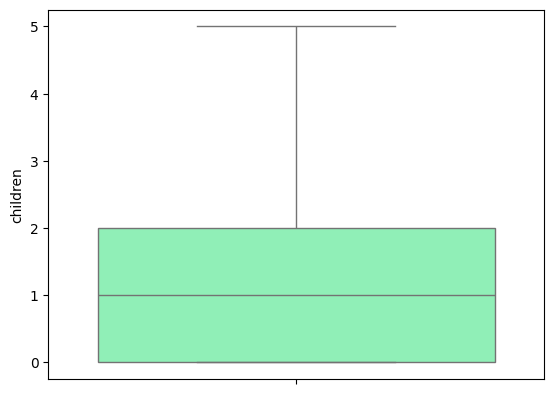

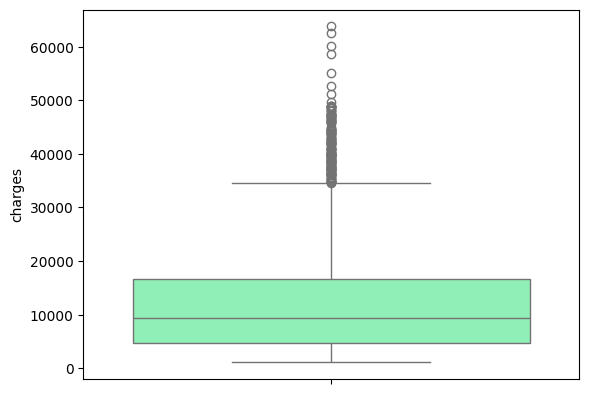

In [ ]:
for col in no_columns:
  sea.boxplot(df[col],palette = 'rainbow')
  plt.show()


<Axes: >

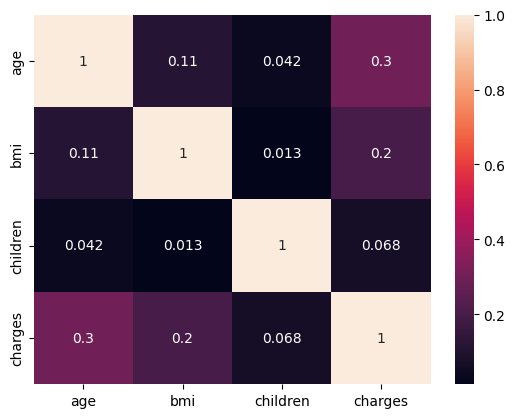

In [ ]:
sea.heatmap(df.corr(numeric_only = True), annot = True)

# **Data Cleaning**

In [ ]:
data_clean = df.copy()
data_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
data_clean.drop_duplicates(inplace = True)


In [ ]:
datasmoke = df.copy()
datasmoke.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
datasmoke['smoker'].value_counts()

,count
smoker,
no,1064
yes,274


In [ ]:
datasmoke['smoker'] = datasmoke['smoker'].map({'yes': 1, 'no': 0})
datasmoke

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,1,southwest,16884.92400
1,18,male,33.770,1,0,southeast,1725.55230
2,28,male,33.000,3,0,southeast,4449.46200
3,33,male,22.705,0,0,northwest,21984.47061
4,32,male,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,0,northwest,10600.54830
1334,18,female,31.920,0,0,northeast,2205.98080
1335,18,female,36.850,0,0,southeast,1629.83350
1336,21,female,25.800,0,0,southwest,2007.94500


In [ ]:
datasmoke.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,1,southwest,16884.92400
1,18,male,33.770,1,0,southeast,1725.55230
2,28,male,33.000,3,0,southeast,4449.46200
3,33,male,22.705,0,0,northwest,21984.47061
4,32,male,28.880,0,0,northwest,3866.85520


In [ ]:
datasmoke['sex'].value_counts()

,count
sex,
male,676
female,662


In [ ]:
datasmoke['sex'] = datasmoke['sex'].map({'male': 1, 'female': 0})


In [ ]:
datasmoke

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830
1334,18,0,31.920,0,0,northeast,2205.98080
1335,18,0,36.850,0,0,southeast,1629.83350
1336,21,0,25.800,0,0,southwest,2007.94500


In [ ]:
datasmoke.rename(columns = {'sex': 'is_female', 'smoker': 'is_smoker'}, inplace = True)
datasmoke

,age,is_female,bmi,children,is_smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830
1334,18,0,31.920,0,0,northeast,2205.98080
1335,18,0,36.850,0,0,southeast,1629.83350
1336,21,0,25.800,0,0,southwest,2007.94500


In [ ]:
datasmoke['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


In [ ]:
datasmoke = pd.get_dummies(datasmoke, columns = ['region'],drop_first= True)
datasmoke

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,True,False,False
1334,18,0,31.920,0,0,2205.98080,False,False,False
1335,18,0,36.850,0,0,1629.83350,False,True,False
1336,21,0,25.800,0,0,2007.94500,False,False,True


In [ ]:
datasmoke = datasmoke.astype('int64')
datasmoke

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27,0,1,16884,0,0,1
1,18,1,33,1,0,1725,0,1,0
2,28,1,33,3,0,4449,0,1,0
3,33,1,22,0,0,21984,1,0,0
4,32,1,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,1,30,3,0,10600,1,0,0
1334,18,0,31,0,0,2205,0,0,0
1335,18,0,36,0,0,1629,0,1,0
1336,21,0,25,0,0,2007,0,0,1


In [ ]:
datasmoke['bmi_category'] = pd.cut(
    datasmoke['bmi'],
    bins = [0,18.5,24.9,29.9,float('inf')],
    labels = ['Underweight','Normal Weight','Overweight','Obesity']
)
datasmoke


In [ ]:
datasmoke = pd.get_dummies(datasmoke, columns = ['bmi_category_Normal Weight','bmi_category_Overweight',	'bmi_category_Obesity'],drop_first= True)

In [ ]:
datasmoke = datasmoke.astype('int64')

In [ ]:
from sklearn.preprocessing import StandardScaler
col = ['age','bmi','children']
scaler = StandardScaler()
datasmoke[col] = scaler.fit_transform(datasmoke[col])
datasmoke

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal Weight_True,bmi_category_Overweight_True,bmi_category_Obesity_True
0,-1.484353,0,0.015084,-0.320476,1,16884,0,0,1,0,1,0
1,-1.484353,1,0.015084,-0.320476,0,1725,0,1,0,0,0,1
2,0.041042,1,0.015084,1.011192,0,4449,0,1,0,0,0,1
3,0.041042,1,-1.426482,-0.320476,0,21984,1,0,0,1,0,0
4,0.041042,1,0.015084,-0.320476,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.041042,1,0.015084,1.011192,0,10600,1,0,0,0,0,1
1334,-1.484353,0,0.015084,-0.320476,0,2205,0,0,0,0,0,1
1335,-1.484353,0,0.015084,-0.320476,0,1629,0,1,0,0,0,1
1336,-1.484353,0,0.015084,-0.320476,0,2007,0,0,1,0,1,0


In [ ]:
datasmoke

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal Weight_True,bmi_category_Overweight_True,bmi_category_Obesity_True
0,-1.484353,0,0.015084,-0.320476,1,16884,0,0,1,0,1,0
1,-1.484353,1,0.015084,-0.320476,0,1725,0,1,0,0,0,1
2,0.041042,1,0.015084,1.011192,0,4449,0,1,0,0,0,1
3,0.041042,1,-1.426482,-0.320476,0,21984,1,0,0,1,0,0
4,0.041042,1,0.015084,-0.320476,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.041042,1,0.015084,1.011192,0,10600,1,0,0,0,0,1
1334,-1.484353,0,0.015084,-0.320476,0,2205,0,0,0,0,0,1
1335,-1.484353,0,0.015084,-0.320476,0,1629,0,1,0,0,0,1
1336,-1.484353,0,0.015084,-0.320476,0,2007,0,0,1,0,1,0


In [ ]:
datasmoke.astype('int64')

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal Weight_True,bmi_category_Overweight_True,bmi_category_Obesity_True
0,-1,0,0,0,1,16884,0,0,1,0,1,0
1,-1,1,0,0,0,1725,0,1,0,0,0,1
2,0,1,0,1,0,4449,0,1,0,0,0,1
3,0,1,-1,0,0,21984,1,0,0,1,0,0
4,0,1,0,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0,1,0,1,0,10600,1,0,0,0,0,1
1334,-1,0,0,0,0,2205,0,0,0,0,0,1
1335,-1,0,0,0,0,1629,0,1,0,0,0,1
1336,-1,0,0,0,0,2007,0,0,1,0,1,0


In [ ]:
datasmoke

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal Weight_True,bmi_category_Overweight_True,bmi_category_Obesity_True
0,-1.484353,0,0.015084,-0.320476,1,16884,0,0,1,0,1,0
1,-1.484353,1,0.015084,-0.320476,0,1725,0,1,0,0,0,1
2,0.041042,1,0.015084,1.011192,0,4449,0,1,0,0,0,1
3,0.041042,1,-1.426482,-0.320476,0,21984,1,0,0,1,0,0
4,0.041042,1,0.015084,-0.320476,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.041042,1,0.015084,1.011192,0,10600,1,0,0,0,0,1
1334,-1.484353,0,0.015084,-0.320476,0,2205,0,0,0,0,0,1
1335,-1.484353,0,0.015084,-0.320476,0,1629,0,1,0,0,0,1
1336,-1.484353,0,0.015084,-0.320476,0,2007,0,0,1,0,1,0


In [ ]:
from scipy.stats import pearsonr
selected_features = ['age', 'bmi', 'children', 'is_female', 'is_smoker', 'region_northwest', 'region_southeast', 'region_southwest','bmi_category_Normal Weight_True',	'bmi_category_Overweight_True',	'bmi_category_Obesity_True']
corelations = {
    feature: pearsonr(datasmoke[feature], datasmoke['charges'])[0]
    for feature in selected_features
}
colrelationdf = pd.DataFrame(list(corelations.items()), columns = ['Feature', 'Correlation'])
colrelationdf


,Feature,Correlation
0,age,0.254519
1,bmi,0.124957
2,children,-0.002692
3,is_female,0.057293
4,is_smoker,0.787251
5,region_northwest,-0.039905
6,region_southeast,0.073981
7,region_southwest,-0.043210
8,bmi_category_Normal Weight_True,-0.103679
9,bmi_category_Overweight_True,-0.120084


In [ ]:
cat_features = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal Weight_True', 'bmi_category_Overweight_True', 'bmi_category_Obesity_True'
]

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

datasmoke['charges_bin'] = pd.qcut(datasmoke['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(datasmoke[col], datasmoke['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
is_smoker,854.020268,0.0,Reject Null (Keep Feature)
region_southeast,15.208814,0.001647,Reject Null (Keep Feature)
is_female,9.532132,0.022992,Reject Null (Keep Feature)
bmi_category_Obesity_True,8.510101,0.036566,Reject Null (Keep Feature)
region_southwest,5.530825,0.136807,Accept Null (Drop Feature)
bmi_category_Overweight_True,4.620089,0.201826,Accept Null (Drop Feature)
bmi_category_Normal Weight_True,3.578987,0.310661,Accept Null (Drop Feature)
region_northwest,1.226112,0.746749,Accept Null (Drop Feature)


In [ ]:
final_df = datasmoke[['age','bmi','children','is_female','is_smoker','bmi_category_Obesity_True','charges','region_southeast']]
final_df

,age,bmi,children,is_female,is_smoker,bmi_category_Obesity_True,charges,region_southeast
0,-1.484353,0.015084,-0.320476,0,1,0,16884,0
1,-1.484353,0.015084,-0.320476,1,0,1,1725,1
2,0.041042,0.015084,1.011192,1,0,1,4449,1
3,0.041042,-1.426482,-0.320476,1,0,0,21984,0
4,0.041042,0.015084,-0.320476,1,0,0,3866,0
...,...,...,...,...,...,...,...,...
1333,0.041042,0.015084,1.011192,1,0,1,10600,0
1334,-1.484353,0.015084,-0.320476,0,0,1,2205,0
1335,-1.484353,0.015084,-0.320476,0,0,1,1629,1
1336,-1.484353,0.015084,-0.320476,0,0,0,2007,0


In [ ]:
hello Here to check my commits